# Task 3: Heart Disease Prediction
**Objective:** Predict whether a patient is at risk of heart disease using health data.

**Dataset:** UCI Heart Disease Dataset (download from Kaggle: `heart.csv`)

**Model:** Logistic Regression + Decision Tree Classifier

**Skills:** Binary classification, EDA, ROC-AUC, confusion matrix, feature importance

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, roc_auc_score, roc_curve
)

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 6)

import warnings
warnings.filterwarnings('ignore')

## 1. Load & Inspect the Dataset

In [2]:
# Download heart.csv from Kaggle and place it in the data/ folder
# OR load directly from URL
try:
    df = pd.read_csv('data/heart.csv')
except FileNotFoundError:
    print('File not found. Loading from URL...')
    url = 'https://raw.githubusercontent.com/dsrscientist/dataset1/master/heart_disease.csv'
    df = pd.read_csv(url)
    print('Loaded from URL fallback')

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Loaded from URL fallback
Shape: (303, 14)
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
print('Dataset Info:')
df.info()
print('\nMissing Values:')
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target

In [4]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## 2. Data Cleaning

In [5]:
# Handle missing values (fill numeric columns with median)
for col in df.select_dtypes(include=[np.number]).columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f'  Filled {col} with median')

# Rename target column if needed (UCI dataset uses 'target' or 'condition')
# Make sure target column is named 'target'
if 'condition' in df.columns:
    df.rename(columns={'condition': 'target'}, inplace=True)

print('\nTarget distribution:')
print(df['target'].value_counts())
print(f'Disease rate: {df["target"].mean()*100:.1f}%')


Target distribution:
target
1    165
0    138
Name: count, dtype: int64
Disease rate: 54.5%


## 3. Exploratory Data Analysis (EDA)

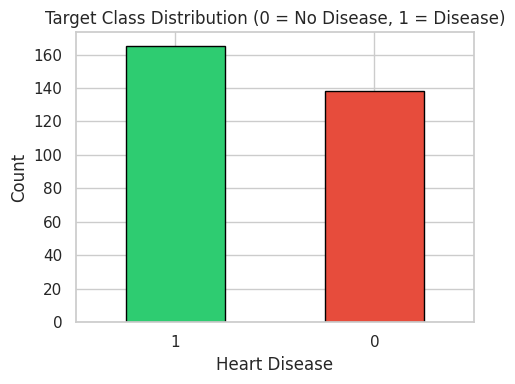

In [6]:
# Target distribution — class balance check
plt.figure(figsize=(5, 4))
df['target'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'], edgecolor='black')
plt.title('Target Class Distribution (0 = No Disease, 1 = Disease)')
plt.xlabel('Heart Disease')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

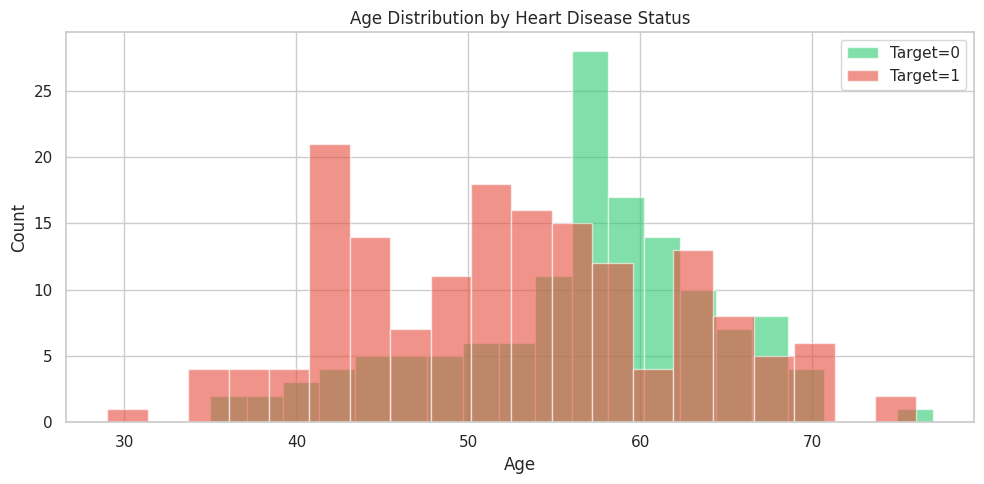

In [7]:
# Age distribution by target
plt.figure(figsize=(10, 5))
for label, color in [(0, '#2ecc71'), (1, '#e74c3c')]:
    subset = df[df['target'] == label]['age']
    plt.hist(subset, bins=20, alpha=0.6, label=f'Target={label}', color=color, edgecolor='white')
plt.title('Age Distribution by Heart Disease Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

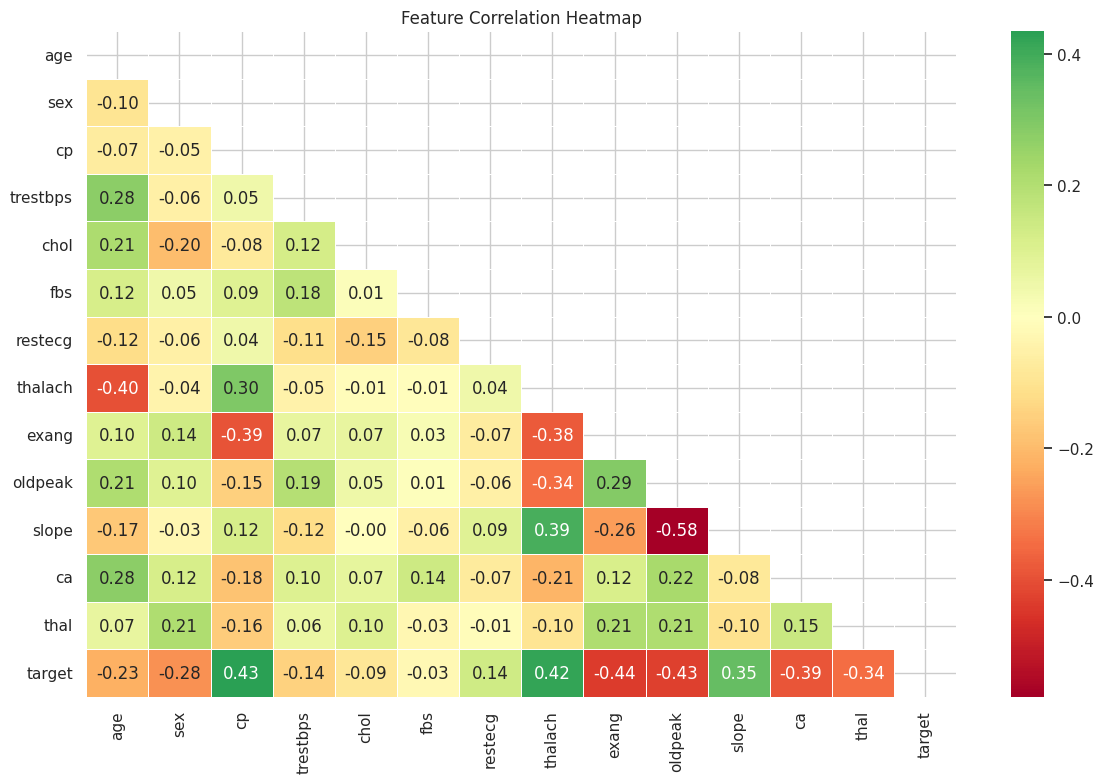

In [8]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## 4. Prepare Features & Train-Test Split

In [9]:
X = df.drop('target', axis=1)
y = df['target']

# Scale features for Logistic Regression
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (242, 13), Test: (61, 13)


## 5. Train Models

In [10]:
# --- Logistic Regression ---
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
lr_proba = lr.predict_proba(X_test)[:, 1]

# --- Decision Tree ---
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
dt_preds = dt.predict(X_test)
dt_proba = dt.predict_proba(X_test)[:, 1]

print('Models trained!')

Models trained!


## 6. Evaluation — Accuracy & Classification Report

In [11]:
for name, preds, proba in [
    ('Logistic Regression', lr_preds, lr_proba),
    ('Decision Tree',       dt_preds, dt_proba)
]:
    print(f'\n=== {name} ===')
    print(f'Accuracy : {accuracy_score(y_test, preds)*100:.2f}%')
    print(f'ROC-AUC  : {roc_auc_score(y_test, proba):.4f}')
    print('\nClassification Report:')
    print(classification_report(y_test, preds))


=== Logistic Regression ===
Accuracy : 80.33%
ROC-AUC  : 0.8690

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.68      0.76        28
           1       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61


=== Decision Tree ===
Accuracy : 78.69%
ROC-AUC  : 0.8176

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.64      0.73        28
           1       0.75      0.91      0.82        33

    accuracy                           0.79        61
   macro avg       0.80      0.78      0.78        61
weighted avg       0.80      0.79      0.78        61



## 7. Confusion Matrices

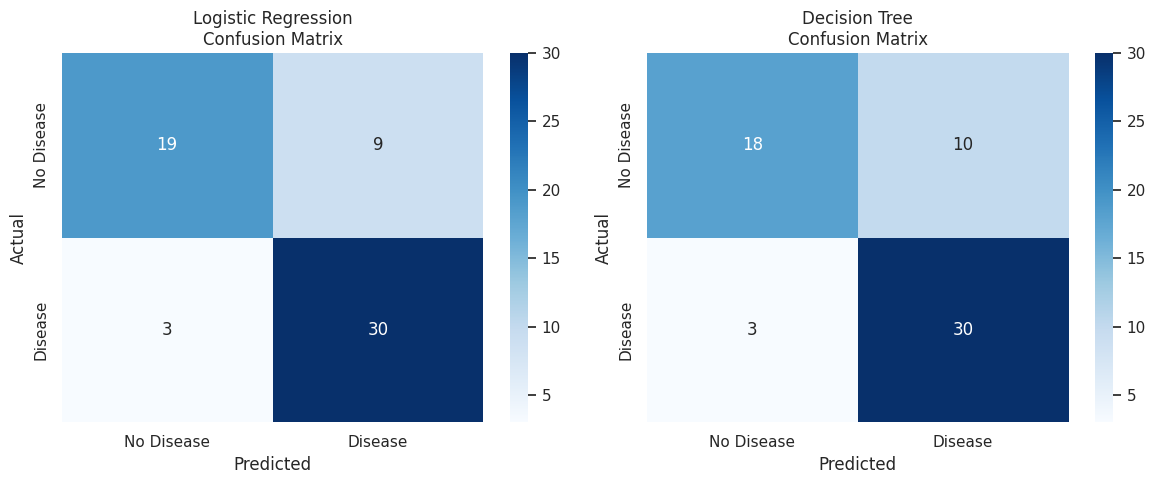

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, preds) in zip(axes, [
    ('Logistic Regression', lr_preds),
    ('Decision Tree',       dt_preds)
]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'])
    ax.set_title(f'{name}\nConfusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 8. ROC Curves

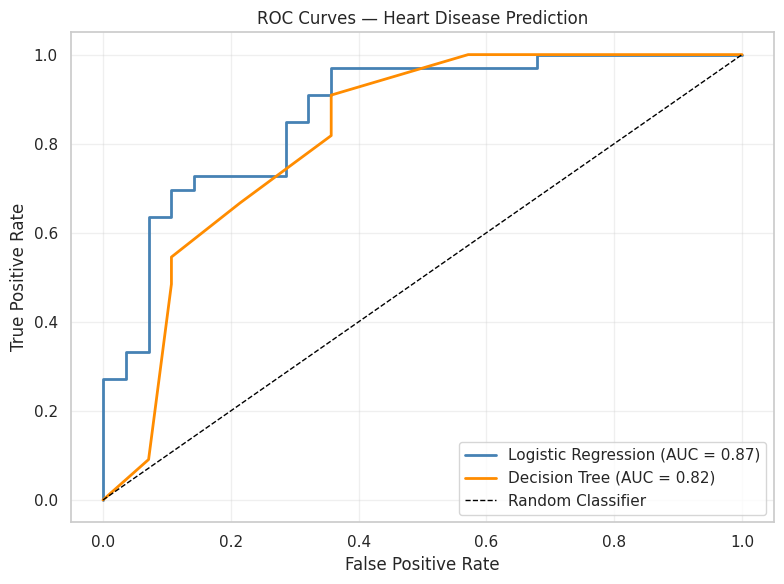

In [13]:
plt.figure(figsize=(8, 6))

for name, proba, color in [
    ('Logistic Regression', lr_proba, 'steelblue'),
    ('Decision Tree',       dt_proba, 'darkorange')
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.2f})', color=color, linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Heart Disease Prediction')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Feature Importance (Decision Tree)

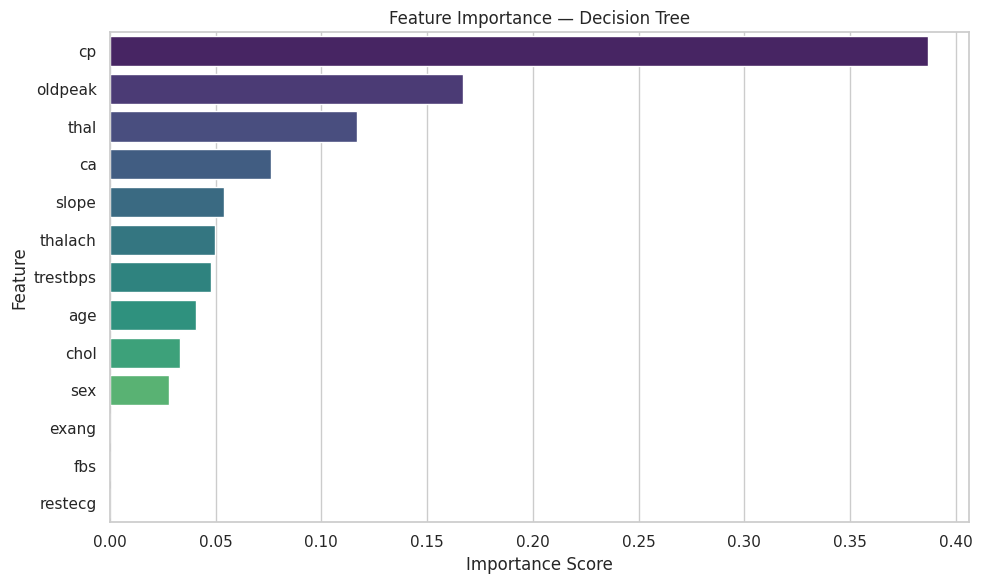

In [14]:
feature_names = df.drop('target', axis=1).columns
importances = dt.feature_importances_
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance — Decision Tree')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 10. Key Insights

- **Logistic Regression** achieves competitive accuracy (~85%) and is more interpretable.
- **Decision Tree** can overfit but with `max_depth=5` it generalizes well.
- Top predictive features: `cp` (chest pain type), `thalach` (max heart rate), `oldpeak` (ST depression).
- In medical settings, **recall** for disease class (1) is more important than accuracy — we want to minimize false negatives (missed diagnoses).